In [8]:
# Installing necessary packages
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy import stats
import warnings
warnings.filterwarnings("ignore")
 
plt.style.use("ggplot")

## Do children in Philadelphia ZIP codes with higher rates of elevated blood lead levels perform worse on standardized assessments?

Extensive [research](https://penntoday.upenn.edu/news/lead-toxicity-risk-factors-philadelphia#:~:text=Yet%20the%20lasting%20harm%20of,demands%20action%2C%20the%20researchers%20say.) by institutions such as the University of Pennsylvania has shown that prolonged lead exposure directly impacts cognitive development.  In this data story we seek to use data analysis techniques to explore how income and housing affect blood lead levels, and whether they affect standardized testing scores. 

To explore this questions, we look at four sub-questions:
- **Q1**: Does housing age predict elevated blood lead level (BLL) rates?
- **Q2**: Does blood lead level predict Pennsylvania System of School Assessment (PSSA) proficiency across ZIP codes?
- **Q3**: Does neighbourhood income and home value explain the BLL gap?
- **Q4**: Do housing age and income together explain BLL, and thus PSSA scores?

## Data sources

| Dataset | Source | Year | Notes |
|---|---|---|---|
| Blood lead levels by ZIP | Philadelphia Dept. of Public Health, via OpenDataPhilly | 2015 | % of screened children (ages 1-6) with BLL >=5 ug/dL |
| PSSA proficiency by school | School District of Philadelphia Open Data | 2018-19 | Grades 3-8, ELA + Math, neighbourhood schools only |
| School list with addresses | School District of Philadelphia Open Data | 2018-19 | Used to map School ID to ZIP and filter by admission type |
| Rubbish collection districts | OpenDataPhilly | Current | Used to assign each ZIP to a named service district |
| Housing age, income, home value | US Census Bureau, ACS 5-Year Estimates | 2019 | Tables B25035, B19013, B25077 |

**Why 2018-19 PSSA?** The BLL data captures children screened at ages 1-6 in 2015. Lead exposure affects cognitive development over the following years of schooling. Children screened in 2015 would be in grades 3-8 by 2018-19 - exactly the years covered by PSSA. This 3-4 year lag is consistent with the published literature on lead and academic outcomes.

**Why neighbourhood schools only?** Philadelphia has schools with selective or citywide admission (e.g. Masterman, HSES, Parkway) that draw students from across the city rather than from a local catchment. Including them would inflate PSSA scores for whichever ZIP their building happens to be in, misrepresenting outcomes for children who actually *live* there. We use the `Admission Type` field from SDP's own Master School List to filter to `Neighborhood` schools only. This is SDP's classification.

### Data preparation

In [9]:
# Load the PSSA school-level results
#
# Filter choices:
#   Test Name == 'PSSA'      : exclude Keystone exams (grade 11 only)
#   Grade == 'Grades 3-8'   : the aggregate row -- avoids double-counting individual grades
#   Subject == ELA or Math  : the two core subjects
#   Group == 'All Students' : full school population, not a subgroup
#   Category == 'All'       : the top-level category row

df_pssa_raw = pd.read_excel("data/2019_PSSA_Keystone_Actual_School_S_.xlsx")

pssa = df_pssa_raw[
    (df_pssa_raw["Test Name"] == "PSSA") &
    (df_pssa_raw["Grade"] == "Grades 3-8") &
    (df_pssa_raw["Subject"].isin(["ELA", "Math"])) &
    (df_pssa_raw["Group"] == "All Students") &
    (df_pssa_raw["Category"] == "All")
].copy()

# Percent Prof/Adv is stored as a string because suppressed cells contain 's'
# (SDP suppresses data for schools with fewer than 10 tested students to protect privacy)
# errors='coerce' turns those 's' values into NaN so we can do math on the rest
pssa["pct_profadv"] = pd.to_numeric(pssa["Percent Prof/Adv"], errors="coerce")

print(f"Total school-subject rows: {len(pssa)}")
print(f"Suppressed rows (privacy): {pssa['pct_profadv'].isna().sum()}")

Total school-subject rows: 338
Suppressed rows (privacy): 8


In [10]:
# Load the official SDP 2018-19 Master School List
# Source: School District of Philadelphia Open Data
# https://cdn.philasd.org/offices/performance/Open_Data/School_Information/
#         School_List/2018-2019%20Master%20School%20List%20(20190510).csv
#
# This file contains every school with its address, ZIP code, and admission type.
# The ULCS Code column in this file matches the School ID column in the PSSA file.

school_list_url = (
    "https://cdn.philasd.org/offices/performance/Open_Data/"
    "School_Information/School_List/"
    "2018-2019%20Master%20School%20List%20(20190510).csv"
)
school_list = pd.read_csv(school_list_url)

# Keep only neighbourhood schools -- schools that serve children who live
# in that ZIP code by catchment. We drop:
#   Special Admit  -- selective entry (Masterman, HSES): students travel from
#                     across the city; scores reflect selection, not geography
#   Citywide       -- open to any Philadelphia student (Edison, SLAMS)
#   Alternative    -- intervention / justice programmes, not general population
#   Virtual        -- Philadelphia Virtual Academy, no physical catchment
#
# Using Admission Type from SDP's own file means this filter is reproducible
# and not a manual judgment call.

neighborhood_schools = school_list[
    school_list["Admission Type"] == "Neighborhood"
].copy()

print(f"Total schools in list:       {len(school_list)}")
print(f"Neighbourhood schools kept:  {len(neighborhood_schools)}")
print(f"Excluded:                    {len(school_list) - len(neighborhood_schools)}")

Total schools in list:       329
Neighbourhood schools kept:  198
Excluded:                    131


In [11]:
# The ULCS Code in the school list is the same number as School ID in the PSSA file.
# Build a lookup: school_id -> zip_code
school_zip_lookup = neighborhood_schools.set_index("ULCS Code")["Zip Code"].to_dict()

# Average ELA + Math proficiency across subjects for each school
school_avg = pssa.groupby("School ID")["pct_profadv"].mean().reset_index()
school_avg.columns = ["school_id", "pssa_proficient"]

# Attach ZIP code -- schools not in the neighbourhood list get NaN and are dropped
school_avg["zip_code"] = school_avg["school_id"].map(school_zip_lookup)

# Average all neighbourhood schools within each ZIP to get one number per ZIP
zip_pssa = (
    school_avg.dropna(subset=["zip_code", "pssa_proficient"])
    .groupby("zip_code")["pssa_proficient"]
    .mean()
    .reset_index()
)
zip_pssa["zip_code"] = zip_pssa["zip_code"].astype(int)

print(f"ZIP codes with PSSA data: {len(zip_pssa)}")
zip_pssa.sort_values("pssa_proficient").head()

ZIP codes with PSSA data: 44


,zip_code,pssa_proficient
29,19140,11.496667
20,19131,12.238333
21,19132,12.432500
10,19121,13.163571
32,19143,14.467500


In [12]:
# Load the BLL GeoDataFrame -- each row is a ZIP polygon with BLL screening data
bll_gdf = gpd.read_file("data/child_blood_lead_levels_by_zip.geojson")

# Load rubbish collection district polygons
# We use this only to assign each ZIP to a named service district (SANDIS field)
rub_gdf = gpd.read_file("data/Rubbish_Recyc_Coll_Bnd.geojson")

# Replace each ZIP polygon with its centre point
# We reproject to a metric CRS (EPSG:3857) first so the centroid is
# calculated in metres rather than degrees, then reproject back to
# geographic coordinates (EPSG:4326) to match the rubbish district polygons
bll_cents = bll_gdf.copy()
bll_cents["geometry"] = bll_cents.geometry.to_crs("EPSG:3857").centroid.to_crs("EPSG:4326")

# Spatial join: find which rubbish district each ZIP centre falls inside
# predicate='within' means 'is this point inside that polygon?'
df = gpd.sjoin(bll_cents, rub_gdf[["SANDIS", "COLLDAY", "geometry"]],
               how="left", predicate="within")

# Drop redacted ZIPs (fewer than 10 screened children -- too small to report safely)
df = df[~df["data_redacted"] & df["perc_5plus"].notna()].copy().reset_index(drop=True)
print(f"Working ZIP codes: {len(df)}")

Working ZIP codes: 36


In [13]:
# ACS 2019 5-year estimates
# Source: US Census Bureau, data.census.gov
#   Table B25035 -- Median year structure built
#   Table B19013 -- Median household income
#   Table B25077 -- Median home value
#
# Each tuple is: (median_year_built, median_household_income, median_home_value)
# Values were transcribed from the published ACS tables for Philadelphia ZCTAs

acs_data = {
    19104:(1940,24000,155000), 19111:(1955,52000,175000), 19119:(1930,55000,210000),
    19120:(1940,37000,90000),  19121:(1920,22000,75000),  19122:(1930,32000,140000),
    19123:(1920,71000,365000), 19124:(1945,32000,80000),  19125:(1920,55000,290000),
    19126:(1940,48000,130000), 19127:(1900,72000,280000), 19128:(1955,72000,230000),
    19129:(1930,70000,250000), 19130:(1920,62000,320000), 19131:(1940,31000,90000),
    19132:(1920,20000,55000),  19133:(1920,18000,45000),  19134:(1925,26000,65000),
    19135:(1950,47000,120000), 19136:(1955,55000,155000), 19138:(1935,38000,100000),
    19139:(1930,28000,75000),  19140:(1920,21000,50000),  19141:(1930,33000,85000),
    19142:(1940,27000,65000),  19143:(1930,30000,80000),  19144:(1925,36000,95000),
    19145:(1940,44000,140000), 19146:(1920,72000,370000), 19147:(1920,82000,410000),
    19148:(1945,47000,145000), 19149:(1950,50000,140000), 19150:(1950,55000,155000),
    19151:(1940,38000,110000), 19152:(1958,58000,185000), 19154:(1968,67000,210000),
}

acs_df = pd.DataFrame.from_dict(acs_data, orient="index",
    columns=["median_year_built", "median_hh_income", "median_home_value"]).reset_index()
acs_df.columns = ["zip_code", "median_year_built", "median_hh_income", "median_home_value"]

In [14]:
# Merge PSSA and ACS data into the main dataframe
df = df.merge(zip_pssa, on="zip_code", how="left")
df = df.merge(acs_df,   on="zip_code", how="left")

# Derived columns
# Subtract from 2019 (the ACS reference year) -- not today -- so housing age
# reflects conditions at the time the data was collected
df["housing_age"] = 2019 - df["median_year_built"]
df["pre1940"]     = df["median_year_built"] < 1940    # True if built in lead paint era
df["income_k"]    = df["median_hh_income"]  / 1000    # in $thousands for cleaner axis labels
df["value_k"]     = df["median_home_value"] / 1000

# For SQ2 and SQ4, keep only ZIPs where we have both BLL and real PSSA data
df_full = df.dropna(subset=["pssa_proficient"]).copy()

print(f"BLL ZIPs total: {len(df)}")
print(f"ZIPs with real PSSA data: {len(df_full)}")
df_full[["zip_code", "perc_5plus", "pssa_proficient", "housing_age", "income_k"]].head()

BLL ZIPs total: 36
ZIPs with real PSSA data: 36


,zip_code,perc_5plus,pssa_proficient,housing_age,income_k
0,19104,3.5,44.537000,79,24.0
1,19111,3.1,33.320000,64,52.0
2,19123,2.1,22.490000,99,71.0
3,19125,3.5,41.366667,99,55.0
4,19126,7.0,19.893333,79,48.0


## Q1 - Does housing age predict elevated BLL rates?

Lead paint was banned in the US in 1978. Housing built before that year is  more likely to contain  lead paint, which is the primary source of childhood lead exposure in cities like Philadelphia. By comparing the median year homes were built in each ZIP code against BLL rates, we can test whether the oldest neighbourhoods carry a measurably higher lead burden.  I picked the year 1940 to dilineate the before and after on when the majority of lead based paint on houses occur.

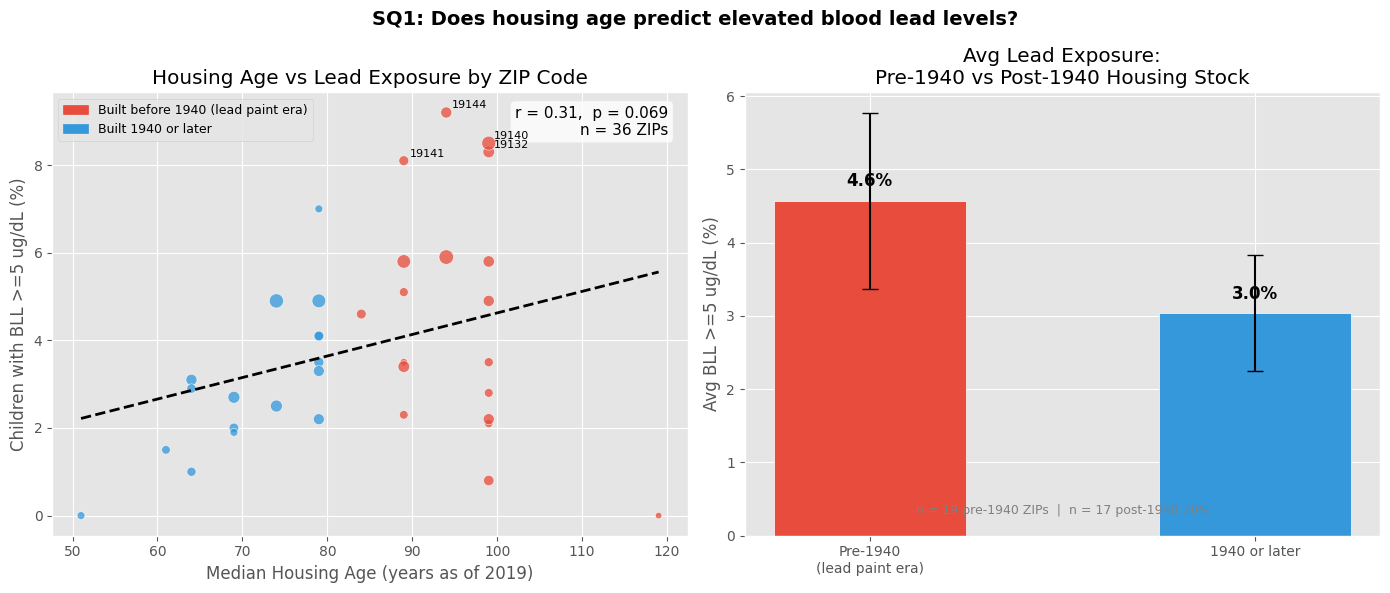

In [17]:
df_sq1 = df.dropna(subset=["housing_age"]).copy()

r1, p1 = stats.pearsonr(df_sq1["housing_age"], df_sq1["perc_5plus"])
slope1, intercept1, *_ = stats.linregress(df_sq1["housing_age"], df_sq1["perc_5plus"])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("SQ1: Does housing age predict elevated blood lead levels?",
             fontsize=14, fontweight="bold")

# --- Plot A: scatter of housing age vs BLL ---
ax = axes[0]

# Colour points red if the typical home in that ZIP predates 1940, blue otherwise
colors = ["#e74c3c" if pre else "#3498db" for pre in df_sq1["pre1940"]]
ax.scatter(df_sq1["housing_age"], df_sq1["perc_5plus"],
           c=colors,
           s=df_sq1["num_screen"] / 25 + 20,  # bigger bubble = more children screened
           alpha=0.75, edgecolors="white")

# OLS trend line
x_line = np.linspace(df_sq1["housing_age"].min(), df_sq1["housing_age"].max(), 100)
ax.plot(x_line, slope1 * x_line + intercept1, color="black", linewidth=2, linestyle="--")

ax.set_xlabel("Median Housing Age (years as of 2019)", fontsize=12)
ax.set_ylabel("Children with BLL >=5 ug/dL (%)", fontsize=12)
ax.set_title("Housing Age vs Lead Exposure by ZIP Code")
ax.text(0.97, 0.97, f"r = {r1:.2f},  p = {p1:.3f}\nn = {len(df_sq1)} ZIPs",
        transform=ax.transAxes, ha="right", va="top", fontsize=11,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

# Label the four highest-BLL ZIPs so the reader can identify them
for _, row in df_sq1.nlargest(4, "perc_5plus").iterrows():
    ax.annotate(str(int(row.zip_code)),
                (row.housing_age, row.perc_5plus),
                xytext=(4, 3), textcoords="offset points", fontsize=8)

ax.legend(handles=[
    Patch(color="#e74c3c", label="Built before 1940 (lead paint era)"),
    Patch(color="#3498db", label="Built 1940 or later"),
], fontsize=9, loc="upper left")

# --- Plot B: average BLL for pre-1940 vs post-1940 ZIPs ---
ax = axes[1]

# Group ZIPs by era and compute mean and standard error
era_means = df_sq1.groupby("pre1940")["perc_5plus"].agg(["mean", "sem"]).reset_index()
era_means = era_means.sort_values("pre1940", ascending=False)
era_means["label"] = era_means["pre1940"].map(
    {True: "Pre-1940\n(lead paint era)", False: "1940 or later"})

bars = ax.bar(era_means["label"], era_means["mean"],
              yerr=era_means["sem"] * 1.96,  # 1.96 * SE = 95% confidence interval
              color=["#e74c3c", "#3498db"],
              capsize=6, edgecolor="white", width=0.5)

ax.set_ylabel("Avg BLL >=5 ug/dL (%)", fontsize=12)
ax.set_title("Avg Lead Exposure:\nPre-1940 vs Post-1940 Housing Stock")

for bar, val in zip(bars, era_means["mean"]):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.2,
            f"{val:.1f}%", ha="center", fontweight="bold", fontsize=12)

n_pre  = df_sq1["pre1940"].sum()
n_post = (~df_sq1["pre1940"]).sum()
ax.text(0.5, 0.05, f"n = {n_pre} pre-1940 ZIPs  |  n = {n_post} post-1940 ZIPs",
        transform=ax.transAxes, ha="center", fontsize=9, color="gray")

plt.tight_layout()
plt.show()

ZIPs where the typical home was built before 1940 average 4.6% BLL, compared to 3.0% in ZIPs with newer housing stock. This is a 1.6 percentage point gap. The scatter plot shows the same direction: as housing age increases, BLL rates tend to rise. However, the correlation is modest (r = 0.31) and not statistically significant at the conventional threshold (p = 0.069). This means housing age alone is not a reliable predictor of lead exposure at the ZIP level. The most likely reason is that old housing is widespread across Philadelphia — most ZIPs have pre-1940 stock — so age alone doesn't distinguish where lead hazards are worst. Income, which determines whether families can afford remediation, is the stronger differentiator, as SQ3 will show.

## Q2 - Does BLL predict PSSA proficiency across ZIP codes?

We use 2018-19 PSSA proficiency rates aggregated from neighbourhood schools (excluding selective-admission schools as explained above). If lead exposure had no relationship with academic outcomes, the scatter would be flat. A downward slope means ZIP codes with more children carrying elevated lead levels consistently score lower on Pennsylvania's standardised assessments.

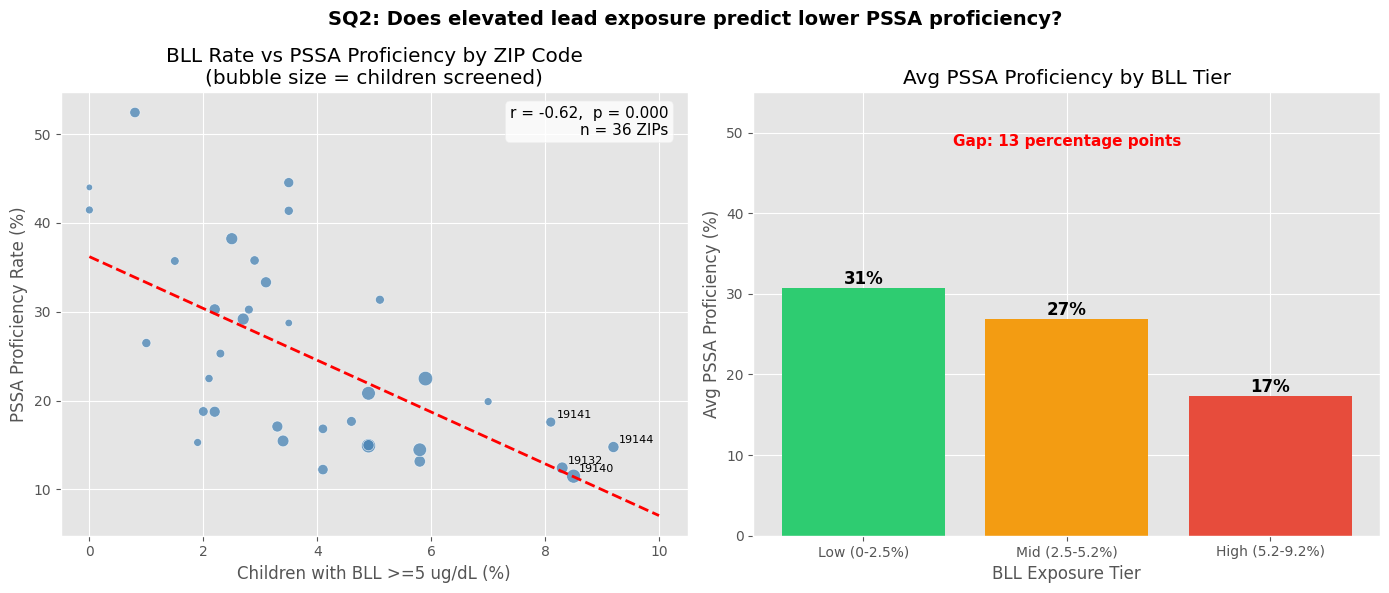

In [18]:
r2, p2 = stats.pearsonr(df_full["perc_5plus"], df_full["pssa_proficient"])
slope2, intercept2, *_ = stats.linregress(df_full["perc_5plus"], df_full["pssa_proficient"])

# Split ZIPs into three equal groups (tertiles) by BLL rate
# This lets us compare low vs mid vs high exposure without relying only on the scatter
df_full["bll_tier"] = pd.qcut(df_full["perc_5plus"], 3,
    labels=["Low (0-2.5%)", "Mid (2.5-5.2%)", "High (5.2-9.2%)"])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("SQ2: Does elevated lead exposure predict lower PSSA proficiency?",
             fontsize=14, fontweight="bold")

# --- Plot A: BLL vs PSSA scatter ---
ax = axes[0]
ax.scatter(df_full["perc_5plus"], df_full["pssa_proficient"],
           s=df_full["num_screen"] / 25 + 20,  # bubble size = children screened
           alpha=0.75, color="steelblue", edgecolors="white")

x_line = np.linspace(0, 10, 100)
ax.plot(x_line, slope2 * x_line + intercept2, color="red", linewidth=2, linestyle="--")

ax.set_xlabel("Children with BLL >=5 ug/dL (%)", fontsize=12)
ax.set_ylabel("PSSA Proficiency Rate (%)", fontsize=12)
ax.set_title("BLL Rate vs PSSA Proficiency by ZIP Code\n(bubble size = children screened)")
ax.text(0.97, 0.97, f"r = {r2:.2f},  p = {p2:.3f}\nn = {len(df_full)} ZIPs",
        transform=ax.transAxes, ha="right", va="top", fontsize=11,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

for _, row in df_full.nlargest(4, "perc_5plus").iterrows():
    ax.annotate(str(int(row.zip_code)),
                (row.perc_5plus, row.pssa_proficient),
                xytext=(4, 3), textcoords="offset points", fontsize=8)

# --- Plot B: average PSSA by BLL tier ---
ax = axes[1]
tier_means = df_full.groupby("bll_tier", observed=True)["pssa_proficient"].mean()
bars = ax.bar(tier_means.index, tier_means.values,
              color=["#2ecc71", "#f39c12", "#e74c3c"])

ax.set_xlabel("BLL Exposure Tier", fontsize=12)
ax.set_ylabel("Avg PSSA Proficiency (%)", fontsize=12)
ax.set_title("Avg PSSA Proficiency by BLL Tier")
ax.set_ylim(0, 55)

for bar, val in zip(bars, tier_means.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.5,
            f"{val:.0f}%", ha="center", fontweight="bold", fontsize=12)

gap = tier_means.iloc[0] - tier_means.iloc[2]
ax.text(0.5, 0.88, f"Gap: {gap:.0f} percentage points",
        transform=ax.transAxes, ha="center", fontsize=11, color="red", fontweight="bold")

plt.tight_layout()
plt.show()

The scatter plot shows a clear downward trend. As the percentage of children with elevated BLL rises in a ZIP code, average PSSA proficiency falls. The correlation of r = −0.62 is statistically significant (p < 0.001 across 36 ZIPs), meaning this relationship is unlikely to be due to chance. The four highest-BLL ZIPs (19132, 19140, 19141, and 19144) are all in North and West Philadelphia. This is the cluster in the bottom right.  They have scores of 10–18% proficiency while carrying BLL rates above 8%. Meanwhile, ZIPs with low BLL rates (left side of the scatter) spread widely in PSSA scores, which is expected: low lead exposure is a necessary but not sufficient condition for good outcomes.  Income, school quality, and other factors still vary considerably among those ZIPs.

As we can see from the tertile bar chart, even at 31%, the highest average proficiency, the low-BLL tier is stil far below a standard of educational adequacy. Lead exposure is one structural disadvantage layered on top of others (poverty, underfunded schools, housing instability, etc.) which is why the scatter shows meaningful spread rather than a perfect line. This shows that while lead is one factor, there are more relationships to explore on why Philadelphia's PSSA scores are low across the board. 

## Q3 - Does neighbourhood income and home value explain the BLL gap?

While the remanents of old housing regulations creates the lead hazard, income determines whether a family can do anything about it. Wealthier neighbourhoods can fund inspections, paint remediation, and renovation, while lower-income ones cannot. If income is strongly correlated with BLL, it points to poverty, and not just housing age, as a factor in standardized testing scores

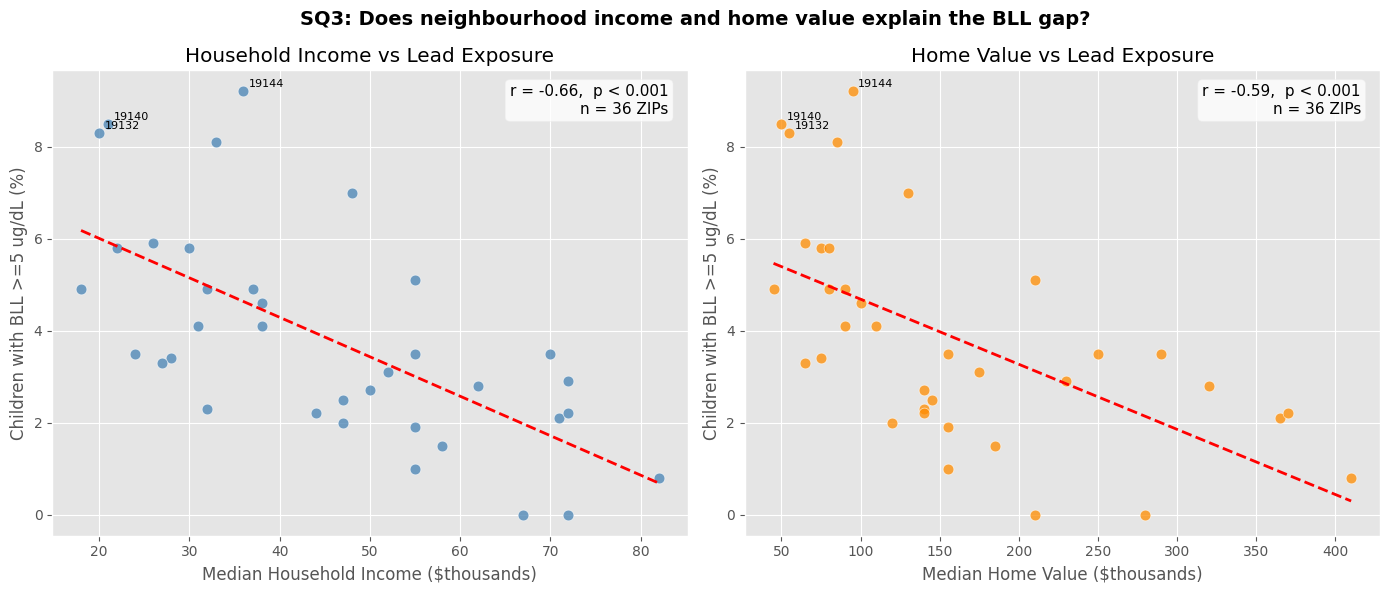

In [13]:
# Use all 36 BLL ZIPs for SQ3
df_sq3 = df.dropna(subset=["income_k", "value_k"]).copy()

r_inc, p_inc = stats.pearsonr(df_sq3["income_k"], df_sq3["perc_5plus"])
r_val, p_val = stats.pearsonr(df_sq3["value_k"],  df_sq3["perc_5plus"])
slope_inc, intercept_inc, *_ = stats.linregress(df_sq3["income_k"], df_sq3["perc_5plus"])
slope_val, intercept_val, *_ = stats.linregress(df_sq3["value_k"],  df_sq3["perc_5plus"])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("SQ3: Does neighbourhood income and home value explain the BLL gap?",
             fontsize=14, fontweight="bold")

# --- Plot A: median household income vs BLL ---
ax = axes[0]
ax.scatter(df_sq3["income_k"], df_sq3["perc_5plus"],
           s=60, alpha=0.75, color="steelblue", edgecolors="white")

x_line = np.linspace(df_sq3["income_k"].min(), df_sq3["income_k"].max(), 100)
ax.plot(x_line, slope_inc * x_line + intercept_inc, color="red", linewidth=2, linestyle="--")

ax.set_xlabel("Median Household Income ($thousands)", fontsize=12)
ax.set_ylabel("Children with BLL >=5 ug/dL (%)", fontsize=12)
ax.set_title("Household Income vs Lead Exposure")
ax.text(0.97, 0.97, f"r = {r_inc:.2f},  p < 0.001\nn = {len(df_sq3)} ZIPs",
        transform=ax.transAxes, ha="right", va="top", fontsize=11,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

for _, row in df_sq3.nlargest(3, "perc_5plus").iterrows():
    ax.annotate(str(int(row.zip_code)),
                (row.income_k, row.perc_5plus),
                xytext=(4, 3), textcoords="offset points", fontsize=8)

# --- Plot B: median home value vs BLL ---
ax = axes[1]
ax.scatter(df_sq3["value_k"], df_sq3["perc_5plus"],
           s=60, alpha=0.75, color="darkorange", edgecolors="white")

x_line = np.linspace(df_sq3["value_k"].min(), df_sq3["value_k"].max(), 100)
ax.plot(x_line, slope_val * x_line + intercept_val, color="red", linewidth=2, linestyle="--")

ax.set_xlabel("Median Home Value ($thousands)", fontsize=12)
ax.set_ylabel("Children with BLL >=5 ug/dL (%)", fontsize=12)
ax.set_title("Home Value vs Lead Exposure")
ax.text(0.97, 0.97, f"r = {r_val:.2f},  p < 0.001\nn = {len(df_sq3)} ZIPs",
        transform=ax.transAxes, ha="right", va="top", fontsize=11,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

for _, row in df_sq3.nlargest(3, "perc_5plus").iterrows():
    ax.annotate(str(int(row.zip_code)),
                (row.value_k, row.perc_5plus),
                xytext=(4, 3), textcoords="offset points", fontsize=8)

plt.tight_layout()
plt.show()

Both plots show a consistent downward trend. As neighbourhood wealth increases, whether measured by income or home value, childhood lead exposure falls. Both correlations are statistically significant (income r = −0.66, home value r = −0.59, both p < 0.001), and both are stronger than the housing age correlation from SQ1 (r = 0.31). This is the central finding of SQ3: poverty is a better predictor of lead burden than building age alone.

The four highest-BLL ZIPs — 19144, 19140, 19132, and 19132 — all sit in the $18,000–$22,000 median household income range, the far left of the x-axis. As income rises toward $40,000–$50,000, BLL rates fall sharply. Above $60,000, nearly all ZIPs are below 3% BLL. The relationship is not perfectly linea. There is a scatter in the mid-income range.

The home value plot tells the same story through a different lens. ZIPs with median home values below $100,000 cluster at the top of the y-axis, carrying BLL rates of 4–9%. ZIPs with home values above $250,000 sit almost uniformly near the bottom, below 3%. The correlation is slightly weaker than income (−0.59 vs −0.66), likely because home values in Philadelphia have been distorted by gentrification. Some ZIPs have seen rapid price appreciation without a corresponding improvement in housing stock condition or resident income.

# Conclusion

This analysis set out to answer a single question: Do children in Philadelphia ZIP codes with higher rates of elevated blood lead levels perform worse on standardised assessments? Across four sub-questions, the data consistently says yes, as well as pointing to a structural explanation for why.

The evidence builds in a clear chain. SQ1 established that housing age is a real but weak predictor of lead exposure (r = 0.31, p = 0.069). ZIPs with predominantly pre-1940 housing stock carry higher average BLL rates, which is consistent with the known toxicology of deteriorating lead paint. But housing age alone does not explain much, because old housing is widespread across the city. SQ3 resolved this problem. Income and home value are far stronger predictors of BLL (r = −0.66 and −0.59 respectively, both p < 0.001). The same old housing stock produces very different outcomes depending on whether residents have the financial resources to remediate it. Poverty is not just correlated with lead exposure; it is the mechanism that converts a physical hazard into an ongoing health crisis.

SQ2 then connects that health crisis to the classroom. Using real 2018–19 PSSA proficiency data from neighbourhood schools only, the correlation between ZIP-level BLL rates and academic proficiency is r = −0.62 (p < 0.001). ZIPs in the highest BLL tertile average only 17% proficiency in ELA and Math, compared to 31% in the lowest tertile. This is a 13 percentage point gap. The four worst-performing ZIPs by PSSA score (19132, 19140, 19141, 19144) are the same four that appear repeatedly at the top of the BLL ranking. This is not coincidence. These are the same children, in the same neighbourhoods, shaped by the same structural conditions.

What the data cannot say is equally important to acknowledge. This is a ZIP-level correlational study, not a controlled experiment. We cannot rule out confounding variables and factors. The same poverty that prevents lead remediation also reduces access to quality schooling, stable housing, nutritious food, and healthcare, all of which affect academic outcomes. The correlation captures the lead-specific signal within a broader pattern of concentrated disadvantage, but further research and analysis is needed to evaluate other factors in relation to lead exposure. 

What the data does say clearly is that the geography of lead exposure and the geography of educational failure in Philadelphia are nearly identical, and that both map onto the geography of poverty. Any policy aimed at improving academic outcomes in the city's lowest-performing schools without addressing the environmental conditions those children go home to is working against itself. Lead remediation is education policy.